# Modelado Predictivo
## Telco Customer Churn - Entrenamiento de Modelos

## 1. Importar Módulos y Cargar Datos

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.train_models import (
    train_logistic_regression, train_decision_tree,
    train_random_forest, train_xgboost, train_all_models
)
from src.evaluate import evaluate_model, plot_confusion_matrix

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# Cargar datos preprocesados
prep_data = joblib.load('../data/processed/preprocessed_data.pkl')
X_train = prep_data['X_train']
X_test = prep_data['X_test']
y_train = prep_data['y_train']
y_test = prep_data['y_test']
feature_names = prep_data['feature_names']

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"Features: {len(feature_names)}")

X_train: (8278, 42)
X_test:  (1409, 42)
y_train: (8278,)
y_test:  (1409,)
Features: 42


## 2. Modelo 1: Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de churn mediante la función sigmoide. Sirve como baseline por su simplicidad e interpretabilidad.


=== ENTRENANDO REGRESIÓN LOGÍSTICA ===
CV ROC-AUC: 0.9195 (+/- 0.0448)

EVALUACIÓN: Regresión Logística
Accuracy: 0.7814
Precision: 0.5702
Recall: 0.7166
F1-Score: 0.6351
ROC-AUC: 0.8514

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      1035
       Churn       0.57      0.72      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409

Matriz guardada en: ../reports/figures/cm_logistic.png


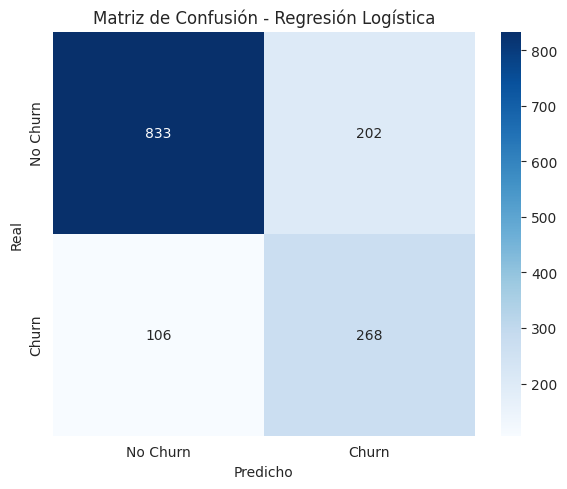

In [2]:
lr = train_logistic_regression(X_train, y_train)
metrics_lr, y_pred_lr, y_proba_lr = evaluate_model(lr, X_test, y_test, 'Regresión Logística')
plot_confusion_matrix(y_test, y_pred_lr, 'Regresión Logística', '../reports/figures/cm_logistic.png')

### Interpretación de Coeficientes

Top 10 coeficientes positivos (aumentan churn):
                            Feature  Coefficient
                   Engagement Score     3.658347
                       Num Services     3.658347
    Multiple Lines_No phone service     1.321684
                    Monthly Charges     1.211128
          Has Dependents or Partner     1.182870
                       Has Internet     0.349587
                      Total Charges     0.327226
              Paperless Billing_Yes     0.227894
  Online Backup_No internet service     0.133151
Online Security_No internet service     0.133151

Top 10 coeficientes negativos (disminuyen churn):
              Feature  Coefficient
       Dependents_Yes    -2.361670
 Tenure Group_6+ años    -2.783147
   Multiple Lines_Yes    -3.472693
    Phone Service_Yes    -3.477910
 Streaming Movies_Yes    -3.673023
     Streaming TV_Yes    -3.697764
Device Protection_Yes    -3.879120
    Online Backup_Yes    -4.044993
     Tech Support_Yes    -4.269064
  Online Sec

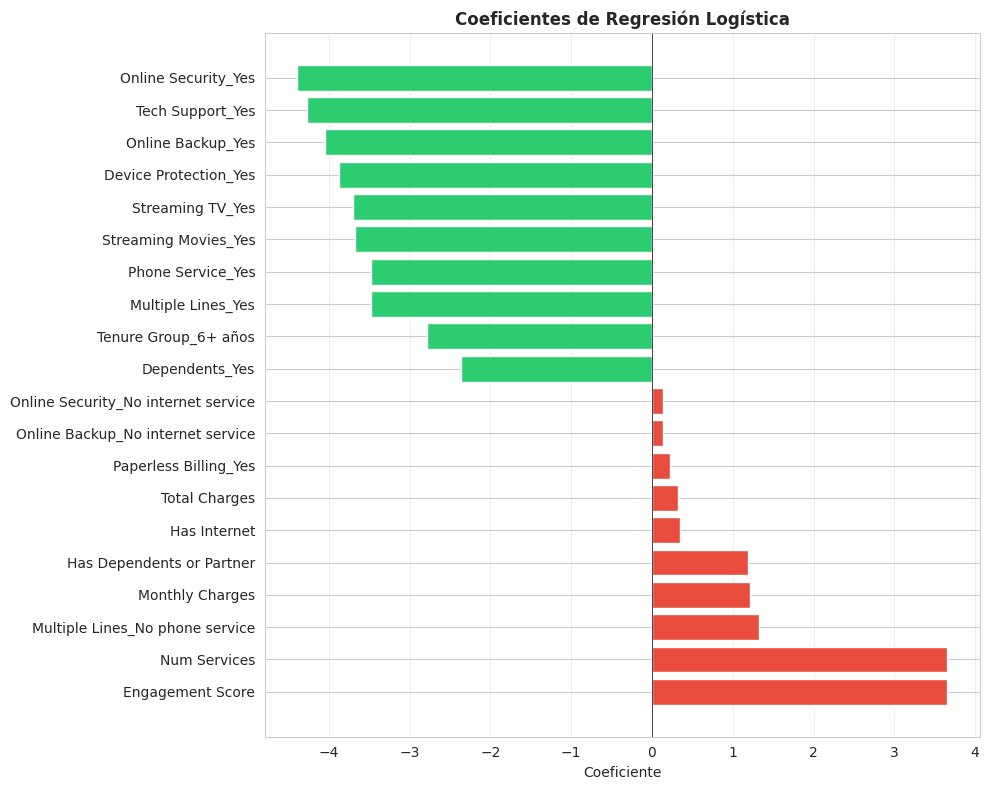

In [3]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Top 10 coeficientes positivos (aumentan churn):")
print(coef_df.head(10).to_string(index=False))
print("\nTop 10 coeficientes negativos (disminuyen churn):")
print(coef_df.tail(10).to_string(index=False))

plt.figure(figsize=(10, 8))
top_coef = pd.concat([coef_df.head(10), coef_df.tail(10)])
colors_coef = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_coef['Coefficient']]
plt.barh(range(len(top_coef)), top_coef['Coefficient'], color=colors_coef)
plt.yticks(range(len(top_coef)), top_coef['Feature'])
plt.xlabel('Coeficiente')
plt.title('Coeficientes de Regresión Logística', fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Modelo 2: Árbol de Decisión

**Fundamento:** Modelo no paramétrico que particiona el espacio de características mediante reglas jerárquicas. Fácil de visualizar e interpretar.


=== ENTRENANDO ÁRBOL DE DECISIÓN ===
Mejores parámetros: {'min_samples_split': 5, 'min_samples_leaf': 10, 'max_depth': 7, 'criterion': 'gini'}
Mejor CV ROC-AUC: 0.8714

EVALUACIÓN: Árbol de Decisión
Accuracy: 0.7417
Precision: 0.5092
Recall: 0.7380
F1-Score: 0.6026
ROC-AUC: 0.8301

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1035
       Churn       0.51      0.74      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.74      0.75      1409

Matriz guardada en: ../reports/figures/cm_decision_tree.png


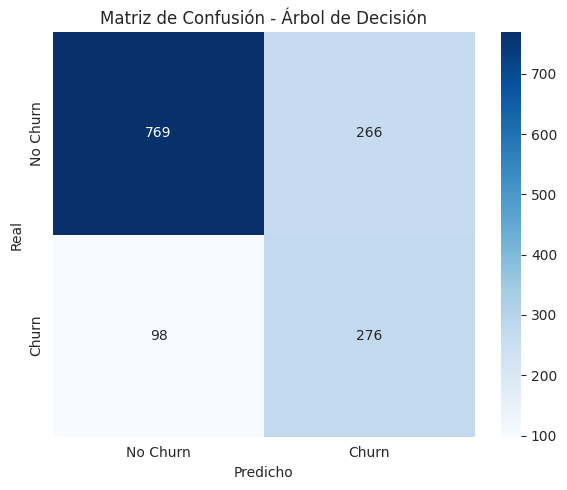

In [4]:
dt, dt_params = train_decision_tree(X_train, y_train)
metrics_dt, y_pred_dt, y_proba_dt = evaluate_model(dt, X_test, y_test, 'Árbol de Decisión')
plot_confusion_matrix(y_test, y_pred_dt, 'Árbol de Decisión', '../reports/figures/cm_decision_tree.png')

### Visualización del Árbol

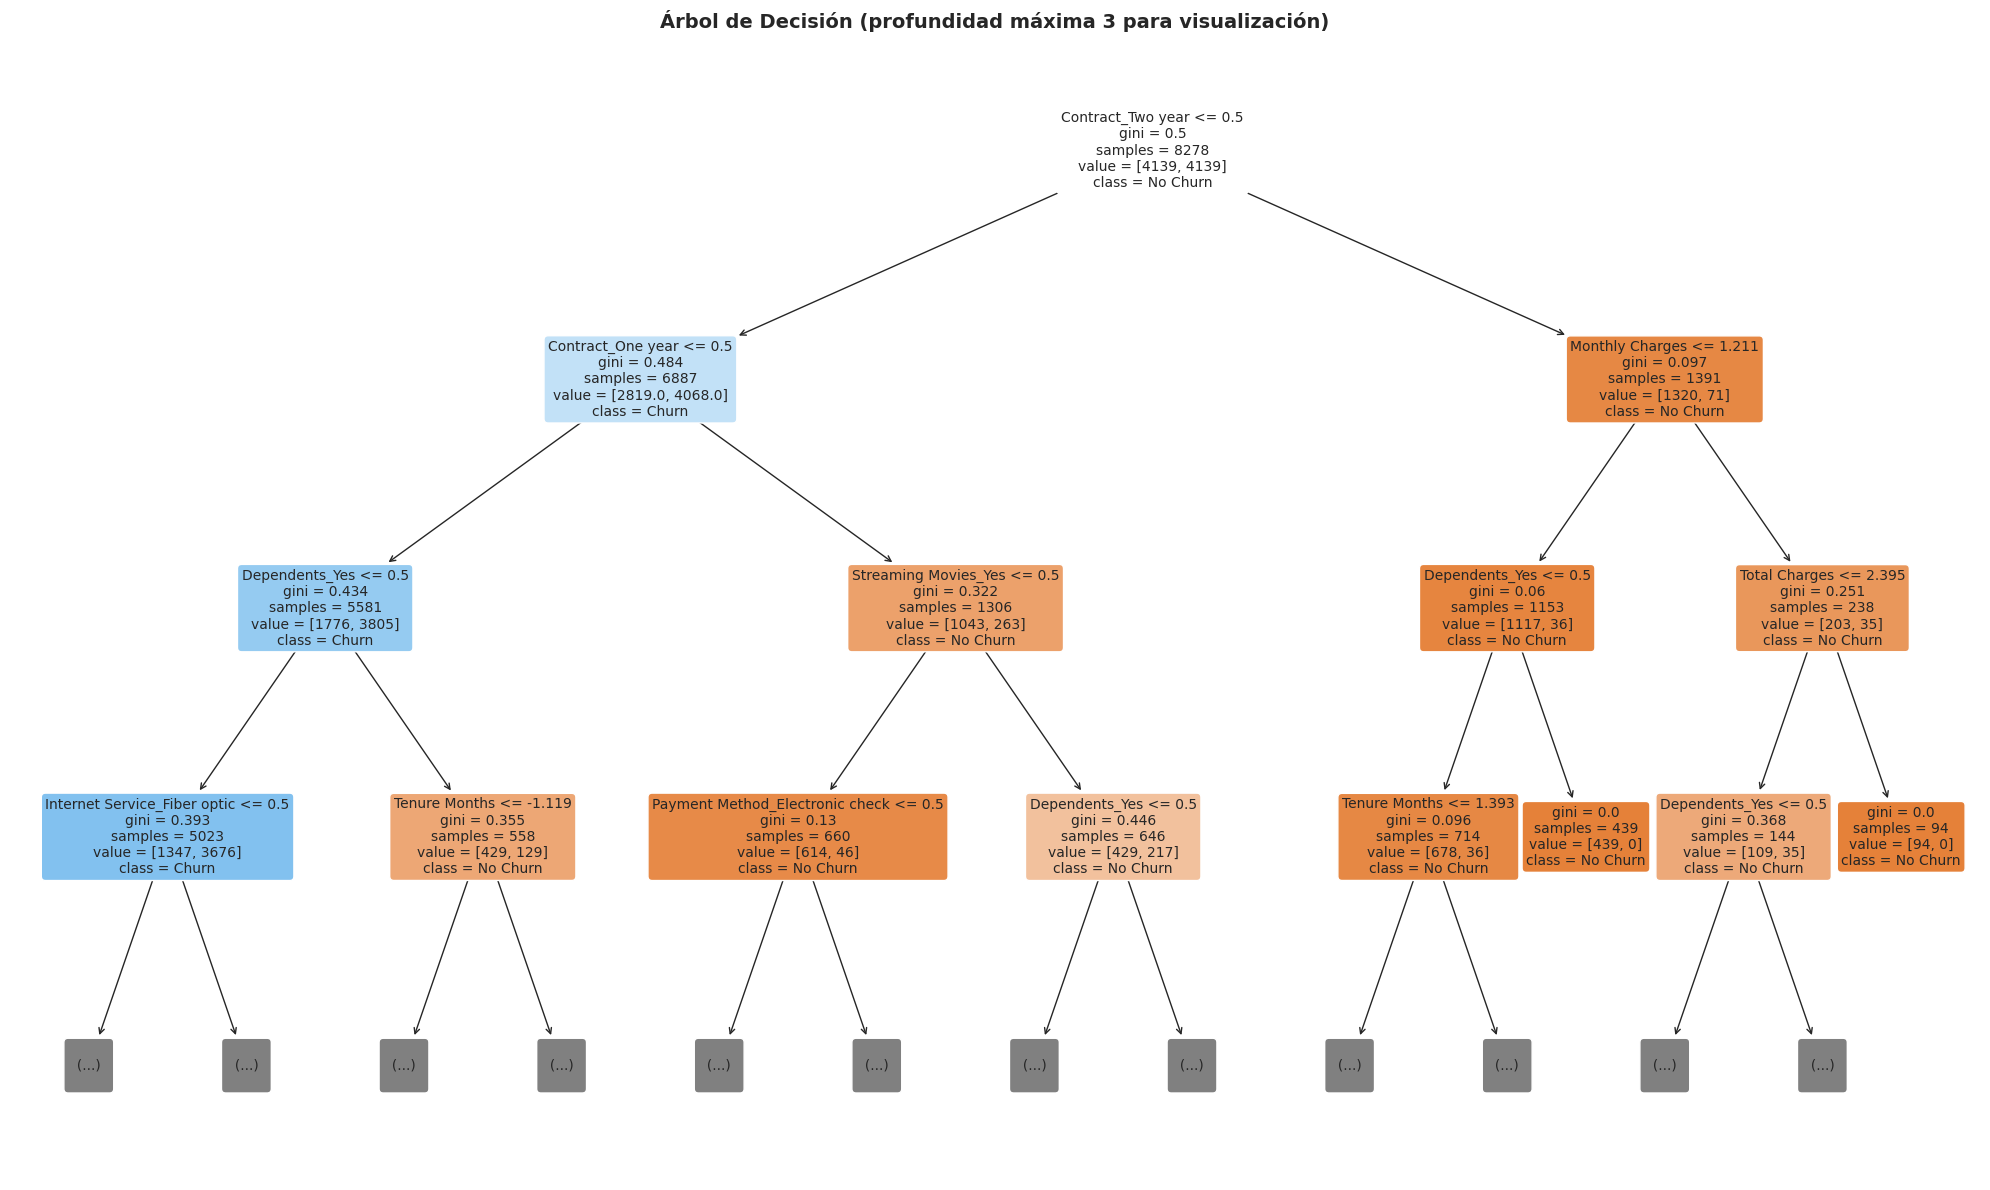

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))
plot_tree(dt, max_depth=3, feature_names=feature_names,
          class_names=['No Churn', 'Churn'], filled=True, rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión (profundidad máxima 3 para visualización)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/decision_tree_visual.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Modelo 3: Random Forest

**Fundamento:** Conjunto de árboles de decisión entrenados con bagging. Reduce la varianza y mejora la precisión respecto a un solo árbol.


=== ENTRENANDO RANDOM FOREST ===
Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Mejor CV ROC-AUC: 0.9353

EVALUACIÓN: Random Forest
Accuracy: 0.7807
Precision: 0.5787
Recall: 0.6390
F1-Score: 0.6074
ROC-AUC: 0.8347

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.85      1035
       Churn       0.58      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409

Matriz guardada en: ../reports/figures/cm_random_forest.png


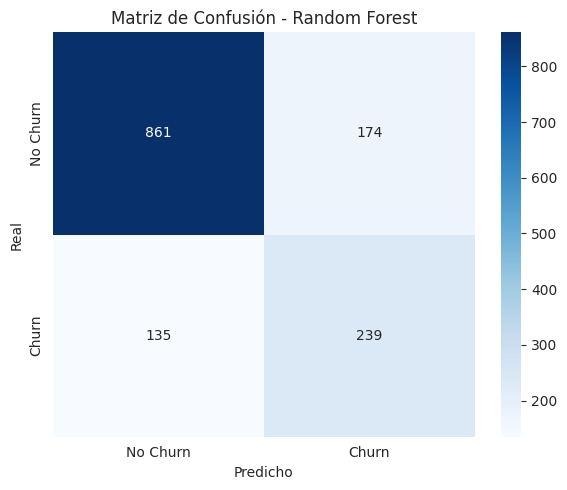

In [6]:
rf, rf_params = train_random_forest(X_train, y_train)
metrics_rf, y_pred_rf, y_proba_rf = evaluate_model(rf, X_test, y_test, 'Random Forest')
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest', '../reports/figures/cm_random_forest.png')

### Importancia de Variables - Random Forest

Importancia guardada en: ../reports/figures/rf_feature_importance.png


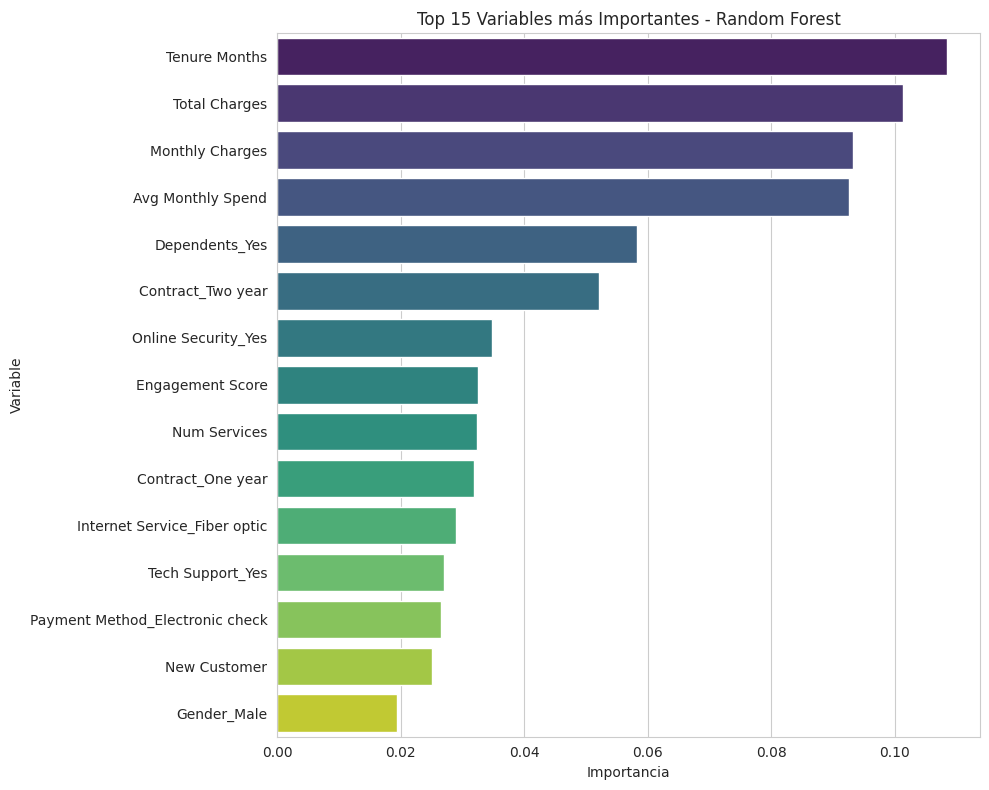

,Feature,Importance
0,Tenure Months,0.108392
2,Total Charges,0.101262
1,Monthly Charges,0.093243
3,Avg Monthly Spend,0.092657
13,Dependents_Yes,0.058279
32,Contract_Two year,0.052048
20,Online Security_Yes,0.034840
9,Engagement Score,0.032588
4,Num Services,0.032329
31,Contract_One year,0.031943


In [7]:
from src.evaluate import plot_feature_importance

feat_imp_rf = plot_feature_importance(
    rf, feature_names, 'Random Forest', top_n=15,
    save_path='../reports/figures/rf_feature_importance.png'
)
feat_imp_rf.head(15)

## 5. Modelo 4: XGBoost

**Fundamento:** Algoritmo de gradient boosting optimizado. Es uno de los modelos más potentes para datos tabulares.


=== ENTRENANDO XGBOOST ===
Mejores parámetros: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Mejor CV ROC-AUC: 0.9355

EVALUACIÓN: XGBoost
Accuracy: 0.7722
Precision: 0.5642
Recall: 0.6230
F1-Score: 0.5921
ROC-AUC: 0.8303

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.84      1035
       Churn       0.56      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.78      1409

Matriz guardada en: ../reports/figures/cm_xgboost.png


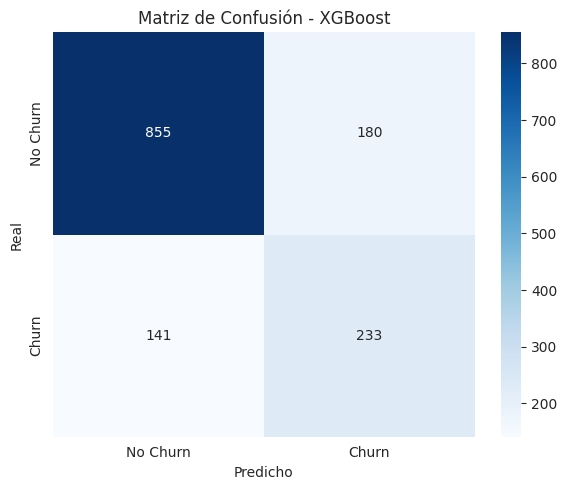

In [8]:
xgb, xgb_params = train_xgboost(X_train, y_train)
metrics_xgb, y_pred_xgb, y_proba_xgb = evaluate_model(xgb, X_test, y_test, 'XGBoost')
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost', '../reports/figures/cm_xgboost.png')

### Importancia de Variables - XGBoost

Importancia guardada en: ../reports/figures/xgb_feature_importance.png


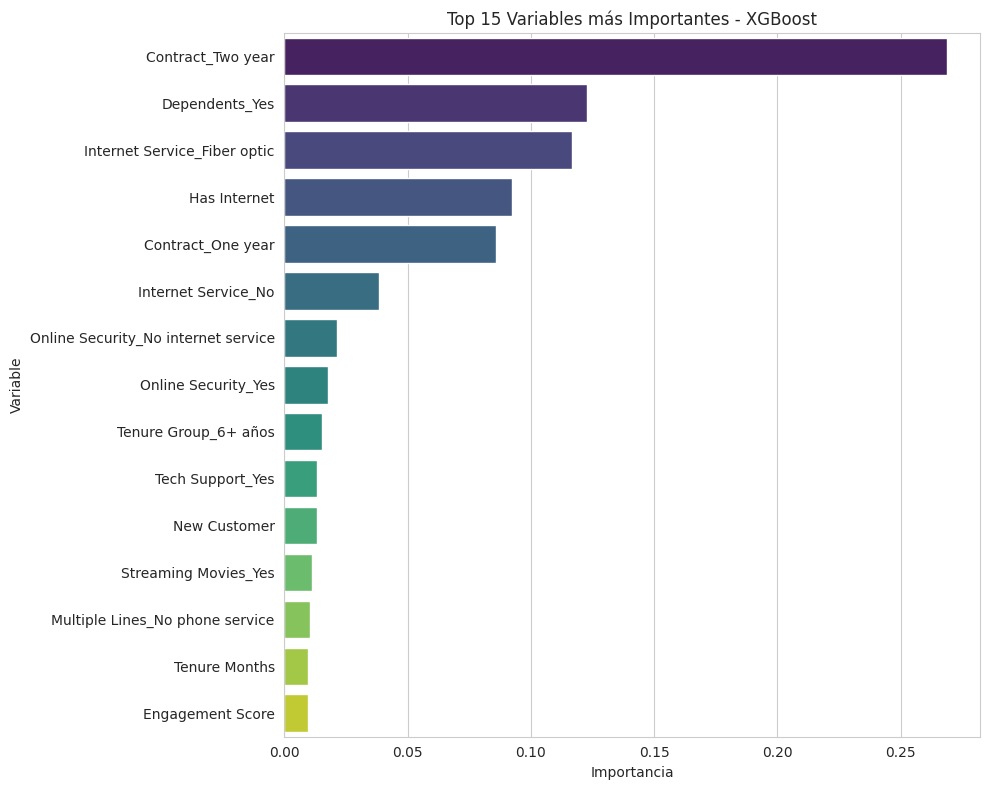

,Feature,Importance
32,Contract_Two year,0.268699
13,Dependents_Yes,0.122820
17,Internet Service_Fiber optic,0.116518
5,Has Internet,0.092189
31,Contract_One year,0.085789
18,Internet Service_No,0.038266
19,Online Security_No internet service,0.021164
20,Online Security_Yes,0.017606
41,Tenure Group_6+ años,0.015093
26,Tech Support_Yes,0.013227


In [9]:
feat_imp_xgb = plot_feature_importance(
    xgb, feature_names, 'XGBoost', top_n=15,
    save_path='../reports/figures/xgb_feature_importance.png'
)
feat_imp_xgb.head(15)

## 6. Guardar Todos los Modelos

In [10]:
from src.train_models import save_model

save_model(lr, 'logistic_regression.pkl')
save_model(dt, 'decision_tree.pkl')
save_model(rf, 'random_forest.pkl')
save_model(xgb, 'xgboost.pkl')

print("\nTodos los modelos guardados exitosamente en la carpeta models/")

Modelo guardado en: models/logistic_regression.pkl
Modelo guardado en: models/decision_tree.pkl
Modelo guardado en: models/random_forest.pkl
Modelo guardado en: models/xgboost.pkl

Todos los modelos guardados exitosamente en la carpeta models/
